In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the AI4I 2020 Predictive Maintenance Dataset
url = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"

df = pd.read_csv(url, compression="zip")

# Clean up column names for easier coding
df = df.drop(columns=['UDI', 'Product ID'])

df.columns = [
    'Type',
    'Air_Temp',
    'Process_Temp',
    'Rotational_Speed',
    'Torque',
    'Tool_Wear',
    'Machine_failure',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (10000, 12)


,Type,Air_Temp,Process_Temp,Rotational_Speed,Torque,Tool_Wear,Machine_failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# One-hot encode the categorical 'Type' column
df = pd.get_dummies(df, columns=['Type'], drop_first=True)

# Create custom physics-based features
df['Temp_Diff'] = df['Process_Temp'] - df['Air_Temp']
df['Power'] = df['Torque'] * df['Rotational_Speed']

# Separate features (X) and target label (y)
# We drop the specific failure mode flags to avoid data leakage
X = df.drop(columns=['Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df['Machine_failure']

print("Feature engineering complete. Available features:")
print(list(X.columns))


Feature engineering complete. Available features:
['Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Type_L', 'Type_M', 'Temp_Diff', 'Power']


In [4]:
import json
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1. Chronological 80/20 train-test split
# ============================================================

split_idx = int(len(X) * 0.80)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 2. Handle class imbalance
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

class_ratio = negative_count / positive_count

print("Normal machines :", negative_count)
print("Failed machines :", positive_count)
print("Class ratio     :", round(class_ratio, 2))


# ============================================================
# 3. Train XGBoost
# ============================================================

model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=class_ratio,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("XGBoost training completed.")


# ============================================================
# 4. Test the model
# ============================================================

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


# ============================================================
# 5. Save trained model
# ============================================================

MODEL_PATH = "predictive_maintenance_model.json"

model.save_model(MODEL_PATH)

print(f"\nModel saved as: {MODEL_PATH}")


# ============================================================
# 6. Save metadata
# ============================================================

metadata = {
    "features": list(X.columns),
    "precision": round(float(precision), 4),
    "recall": round(float(recall), 4),
    "f1_score": round(float(f1), 4),
    "roc_auc": round(float(roc_auc), 4),
    "train_samples": int(len(X_train)),
    "test_samples": int(len(X_test)),
    "class_ratio": round(float(class_ratio), 4)
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved as: model_metadata.json")

Training samples: 8000
Testing samples : 2000
Normal machines : 7700
Failed machines : 300
Class ratio     : 25.67
XGBoost training completed.

MODEL PERFORMANCE

Confusion Matrix:
[[1933   28]
 [  13   26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1961
           1       0.48      0.67      0.56        39

    accuracy                           0.98      2000
   macro avg       0.74      0.83      0.77      2000
weighted avg       0.98      0.98      0.98      2000

Precision : 0.4815
Recall    : 0.6667
F1 Score  : 0.5591
ROC-AUC   : 0.9664

Model saved as: predictive_maintenance_model.json
Metadata saved as: model_metadata.json


In [5]:
# Predict on the unseen test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Display performance metrics
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


--- Confusion Matrix ---
[[1933   28]
 [  13   26]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1961
           1       0.48      0.67      0.56        39

    accuracy                           0.98      2000
   macro avg       0.74      0.83      0.77      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC Score: 0.9664


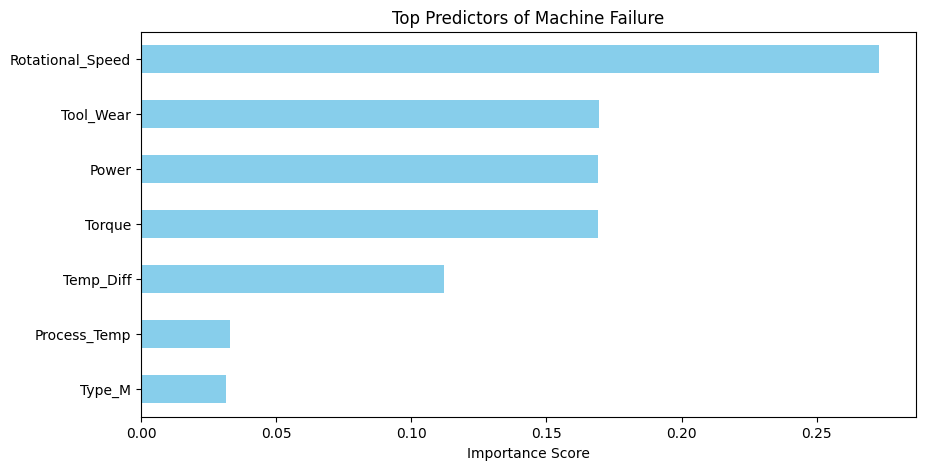

In [6]:
# Plot what features the model found most valuable
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 5))
importances.nlargest(7).plot(kind='barh', color='skyblue')
plt.title('Top Predictors of Machine Failure')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # Put the highest importance at the top
plt.show()


In [9]:
%%writefile predictive_maintenance_app.py

import json
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st
from xgboost import XGBClassifier


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Predictive Maintenance Dashboard",
    page_icon="⚙️",
    layout="wide"
)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent

MODEL_PATH = BASE_DIR / "predictive_maintenance_model.json"
METADATA_PATH = BASE_DIR / "model_metadata.json"


# ============================================================
# LOAD MODEL
# ============================================================

@st.cache_resource
def load_model():
    model = XGBClassifier()
    model.load_model(MODEL_PATH)
    return model


@st.cache_data
def load_metadata():
    with open(METADATA_PATH, "r") as file:
        return json.load(file)


# ============================================================
# CHECK REQUIRED FILES
# ============================================================

if not MODEL_PATH.exists():
    st.error(
        "Trained model not found. "
        "Run the predictive_maintenance.ipynb notebook first "
        "to generate predictive_maintenance_model.json."
    )
    st.stop()


if not METADATA_PATH.exists():
    st.error(
        "Model metadata not found. "
        "Run the predictive_maintenance.ipynb notebook first."
    )
    st.stop()


model = load_model()
metadata = load_metadata()


# ============================================================
# TITLE
# ============================================================

st.title("Predictive Maintenance Dashboard")

st.write(
    "Predict the probability of machine failure using "
    "a trained XGBoost classification model."
)

st.divider()


# ============================================================
# MODEL PERFORMANCE
# ============================================================

st.subheader("Model Performance")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Precision",
        f"{metadata['precision']:.2%}"
    )

with col2:
    st.metric(
        "Recall",
        f"{metadata['recall']:.2%}"
    )

with col3:
    st.metric(
        "F1 Score",
        f"{metadata['f1_score']:.2%}"
    )

with col4:
    st.metric(
        "ROC-AUC",
        f"{metadata['roc_auc']:.4f}"
    )

st.divider()


# ============================================================
# SIDEBAR INPUTS
# ============================================================

st.sidebar.header("Machine Telemetry")

air_temp = st.sidebar.slider(
    "Air Temperature (K)",
    min_value=295.0,
    max_value=305.0,
    value=300.0,
    step=0.1
)

process_temp = st.sidebar.slider(
    "Process Temperature (K)",
    min_value=305.0,
    max_value=315.0,
    value=310.0,
    step=0.1
)

rot_speed = st.sidebar.slider(
    "Rotational Speed (rpm)",
    min_value=1100,
    max_value=2800,
    value=1500,
    step=10
)

torque = st.sidebar.slider(
    "Torque (Nm)",
    min_value=3.0,
    max_value=76.0,
    value=40.0,
    step=0.1
)

tool_wear = st.sidebar.slider(
    "Tool Wear (min)",
    min_value=0,
    max_value=250,
    value=100,
    step=1
)

machine_type = st.sidebar.selectbox(
    "Machine Quality Type",
    ["Low (L)", "Medium (M)", "High (H)"]
)


# ============================================================
# FEATURE ENGINEERING
# ============================================================

temp_diff = process_temp - air_temp
power = torque * rot_speed

type_l = 1 if machine_type == "Low (L)" else 0
type_m = 1 if machine_type == "Medium (M)" else 0


# ============================================================
# CREATE INPUT DATAFRAME
# ============================================================

input_data = pd.DataFrame([{
    "Air_Temp": air_temp,
    "Process_Temp": process_temp,
    "Rotational_Speed": rot_speed,
    "Torque": torque,
    "Tool_Wear": tool_wear,
    "Type_L": type_l,
    "Type_M": type_m,
    "Temp_Diff": temp_diff,
    "Power": power
}])


# Make absolutely sure feature order matches training
feature_order = [
    "Air_Temp",
    "Process_Temp",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Type_L",
    "Type_M",
    "Temp_Diff",
    "Power"
]

input_data = input_data.reindex(
    columns=feature_order,
    fill_value=0
)


# ============================================================
# DISPLAY CURRENT TELEMETRY
# ============================================================

st.subheader("Current Machine Telemetry")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Air Temperature",
        f"{air_temp:.1f} K"
    )

with col2:
    st.metric(
        "Process Temperature",
        f"{process_temp:.1f} K"
    )

with col3:
    st.metric(
        "Rotational Speed",
        f"{rot_speed:,} rpm"
    )

with col4:
    st.metric(
        "Tool Wear",
        f"{tool_wear} min"
    )


col1, col2 = st.columns(2)

with col1:
    st.metric(
        "Temperature Difference",
        f"{temp_diff:.2f} K"
    )

with col2:
    st.metric(
        "Power",
        f"{power:,.0f}"
    )


st.divider()


# ============================================================
# PREDICTION
# ============================================================

if st.button(
    "Analyze Equipment Health",
    type="primary",
    use_container_width=True
):

    # Actual XGBoost prediction
    failure_probability = model.predict_proba(
        input_data
    )[0][1]

    prediction = model.predict(
        input_data
    )[0]


    # ========================================================
    # DISPLAY FAILURE PROBABILITY
    # ========================================================

    st.subheader("Failure Risk")

    probability_percent = failure_probability * 100

    st.progress(
        float(failure_probability),
        text=f"Failure Probability: {probability_percent:.2f}%"
    )


    # ========================================================
    # HEALTH STATUS
    # ========================================================

    if failure_probability >= 0.65:

        status = "CRITICAL"
        recommendation = (
            "High probability of machine failure. "
            "Immediate inspection and maintenance is recommended."
        )

        st.error(
            f"CRITICAL ALERT\n\n"
            f"Predicted failure probability: "
            f"{probability_percent:.2f}%"
        )

    elif failure_probability >= 0.25:

        status = "WARNING"
        recommendation = (
            "Moderate failure probability detected. "
            "Schedule an inspection and monitor machine telemetry."
        )

        st.warning(
            f"WARNING\n\n"
            f"Predicted failure probability: "
            f"{probability_percent:.2f}%"
        )

    else:

        status = "NORMAL"
        recommendation = (
            "Machine is operating within the model's "
            "low-risk range. Continue normal monitoring."
        )

        st.success(
            f"NORMAL\n\n"
            f"Predicted failure probability: "
            f"{probability_percent:.2f}%"
        )


    # ========================================================
    # RESULTS
    # ========================================================

    st.subheader("Maintenance Recommendation")

    st.info(recommendation)


    # ========================================================
    # PREDICTION DETAILS
    # ========================================================

    st.subheader("Prediction Details")

    result_col1, result_col2, result_col3 = st.columns(3)

    with result_col1:
        st.metric(
            "Model Prediction",
            "FAILURE" if prediction == 1 else "NORMAL"
        )

    with result_col2:
        st.metric(
            "Failure Probability",
            f"{probability_percent:.2f}%"
        )

    with result_col3:
        st.metric(
            "Health Status",
            status
        )


    # ========================================================
    # INPUT DATA
    # ========================================================

    with st.expander("View Model Input"):

        display_data = input_data.copy()

        st.dataframe(
            display_data,
            use_container_width=True
        )

Overwriting predictive_maintenance_app.py
